# Import bibliotek

In [ ]:
!pip install optuna
import optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 12.2 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib

from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, f1_score, log_loss
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns


# Wczytanie i eksploracja danych

In [2]:
df = pd.read_csv("matches-prepared.csv")
df.head()

,Division,MatchDate,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,Form5Away,...,OddAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB,match_result,total_goals,over25_binary
0,F1,2000-07-28,Marseille,Troyes,1686.34,1586.57,0.0,0.0,0.0,0.0,...,4.3,NaN,NaN,NaN,NaN,NaN,NaN,Win,4.0,1
1,F1,2000-07-28,Paris SG,Strasbourg,1714.89,1642.51,0.0,0.0,0.0,0.0,...,4.6,NaN,NaN,NaN,NaN,NaN,NaN,Win,4.0,1
2,F2,2000-07-28,Wasquehal,Nancy,1465.08,1633.80,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Loss,1.0,0
3,F1,2000-07-29,Auxerre,Sedan,1635.58,1624.22,0.0,0.0,0.0,0.0,...,3.9,NaN,NaN,NaN,NaN,NaN,NaN,Loss,1.0,0
4,F1,2000-07-29,Bordeaux,Metz,1734.34,1673.11,0.0,0.0,0.0,0.0,...,4.3,NaN,NaN,NaN,NaN,NaN,NaN,Draw,2.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230554 entries, 0 to 230553
Data columns (total 40 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Division       230554 non-null  object 
 1   MatchDate      230554 non-null  object 
 2   HomeTeam       230554 non-null  object 
 3   AwayTeam       230554 non-null  object 
 4   HomeElo        141595 non-null  float64
 5   AwayElo        141526 non-null  float64
 6   Form3Home      229056 non-null  float64
 7   Form5Home      229056 non-null  float64
 8   Form3Away      229056 non-null  float64
 9   Form5Away      229056 non-null  float64
 10  FTHome         230554 non-null  float64
 11  FTAway         230554 non-null  float64
 12  FTResult       230554 non-null  object 
 13  HTHome         175976 non-null  float64
 14  HTAway         175976 non-null  float64
 15  HTResult       175976 non-null  object 
 16  HomeShots      114735 non-null  float64
 17  AwayShots      114738 non-nul

In [4]:
# Usuniecie kolumn gdzie brakuje wiecej niz 50%
threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=threshold)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230554 entries, 0 to 230553
Data columns (total 26 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Division       230554 non-null  object 
 1   MatchDate      230554 non-null  object 
 2   HomeTeam       230554 non-null  object 
 3   AwayTeam       230554 non-null  object 
 4   HomeElo        141595 non-null  float64
 5   AwayElo        141526 non-null  float64
 6   Form3Home      229056 non-null  float64
 7   Form5Home      229056 non-null  float64
 8   Form3Away      229056 non-null  float64
 9   Form5Away      229056 non-null  float64
 10  FTHome         230554 non-null  float64
 11  FTAway         230554 non-null  float64
 12  FTResult       230554 non-null  object 
 13  HTHome         175976 non-null  float64
 14  HTAway         175976 non-null  float64
 15  HTResult       175976 non-null  object 
 16  HomeYellow     119298 non-null  float64
 17  AwayYellow     119299 non-nul

# Inżynieria cech (Feature engineering)


Utworzenie zmiennej docelowej

In [5]:
mapping = {
    "Loss": 0,
    "Draw": 1,
    "Win": 2
}

df["match_result_encoded"] = df["match_result"].map(mapping)
print(df["match_result_encoded"].value_counts())

match_result_encoded
2    102873
0     66560
1     61121
Name: count, dtype: int64


Wypełnienie brakujących wartości i utworzenie nowych cech

In [6]:
df["MatchDate"] = pd.to_datetime(df["MatchDate"])

df["HomeElo"] = df.groupby("Division")["HomeElo"].transform(
    lambda x: x.fillna(x.mean())
)

df["AwayElo"] = df.groupby("Division")["AwayElo"].transform(
    lambda x: x.fillna(x.mean())
)

#jesli caly division nie ma elo, to wypelniamy srednią globalną
global_home_elo_mean = df["HomeElo"].mean()
global_away_elo_mean = df["AwayElo"].mean()
df["HomeElo"] = df["HomeElo"].fillna(global_home_elo_mean)
df["AwayElo"] = df["AwayElo"].fillna(global_away_elo_mean)

df["elo_diff"] = df["HomeElo"] - df["AwayElo"]

form_cols = ["Form3Home", "Form5Home", "Form3Away", "Form5Away"]
df[form_cols] = df[form_cols].fillna(0)

odd_cols = ["OddHome", "OddDraw", "OddAway"]
df[odd_cols] = df[odd_cols].replace(0, np.nan)
df[odd_cols] = df[odd_cols].fillna(df[odd_cols].median())

df['FormDiff3'] = df['Form3Home'] - df['Form3Away']
df['FormDiff5'] = df['Form5Home'] - df['Form5Away']

df['ProbHome'] = 1 / df['OddHome']
df['ProbDraw'] = 1 / df['OddDraw']
df['ProbAway'] = 1 / df['OddAway']

In [7]:
df = df.sort_values('MatchDate').reset_index(drop=True)

# Reshape to team-centric view

home_df = df[['MatchDate', 'Division', 'HomeTeam', 'FTHome', 'FTAway']].rename(
    columns={'HomeTeam': 'Team', 'FTHome': 'GoalsScored', 'FTAway': 'GoalsConceded'}
)
home_df['IsHome'] = 1

away_df = df[['MatchDate', 'Division', 'AwayTeam', 'FTAway', 'FTHome']].rename(
    columns={'AwayTeam': 'Team', 'FTAway': 'GoalsScored', 'FTHome': 'GoalsConceded'}
)
away_df['IsHome'] = 0

team_stats = pd.concat([home_df, away_df]).sort_values(['MatchDate'])

# Calculate league averages(Per Division)

# Average Home Goals per Division
div_stats = df.groupby(['Division']).expanding().mean(numeric_only=True)['FTHome'].reset_index()
league_avg = df.groupby('Division')[['FTHome', 'FTAway']].transform(
    lambda x: x.shift().expanding().mean()
)
df['LeagueAvgHome'] = league_avg['FTHome']
df['LeagueAvgAway'] = league_avg['FTAway']

# Fill NaN at start of season with a reasonable default (e.g., 1.3 goals)
df['LeagueAvgHome'] = df['LeagueAvgHome'].fillna(1.35)
df['LeagueAvgAway'] = df['LeagueAvgAway'].fillna(1.10)

# Calculate team strengths (Expanding Mean)
stats_cols = ['GoalsScored', 'GoalsConceded']
team_stats[stats_cols] = team_stats.groupby(['Team', 'Division'])[stats_cols].transform(
    lambda x: x.shift().expanding().mean()
)

team_stats[stats_cols] = team_stats[stats_cols].fillna(1.3)

# Merge Home Team Stats
df = df.merge(
    team_stats[team_stats['IsHome'] == 1][['MatchDate', 'Team', 'GoalsScored', 'GoalsConceded']],
    left_on=['MatchDate', 'HomeTeam'],
    right_on=['MatchDate', 'Team'],
    suffixes=('', '_HomeHist')
).drop(columns=['Team'])

# Merge Away Team Stats
df = df.merge(
    team_stats[team_stats['IsHome'] == 0][['MatchDate', 'Team', 'GoalsScored', 'GoalsConceded']],
    left_on=['MatchDate', 'AwayTeam'],
    right_on=['MatchDate', 'Team'],
    suffixes=('', '_AwayHist')
).drop(columns=['Team'])


# Calculate xG

df['LeagueAvgHome'] = df['LeagueAvgHome'].replace(0, 1.35)
df['LeagueAvgAway'] = df['LeagueAvgAway'].replace(0, 1.10)

df['Home_Att_Str'] = df['GoalsScored'] / df['LeagueAvgHome']
df['Home_Att_Str'] = df['Home_Att_Str'].fillna(1.0)

df['Away_Def_Str'] = df['GoalsConceded_AwayHist'] / df['LeagueAvgHome']
df['Away_Def_Str'] = df['Away_Def_Str'].fillna(1.0)

df['xG_Home'] = df['Home_Att_Str'] * df['Away_Def_Str'] * df['LeagueAvgHome']

df['Away_Att_Str'] = df['GoalsScored_AwayHist'] / df['LeagueAvgAway']
df['Away_Att_Str'] = df['Away_Att_Str'].fillna(1.0)

df['Home_Def_Str'] = df['GoalsConceded'] / df['LeagueAvgAway']
df['Home_Def_Str'] = df['Home_Def_Str'].fillna(1.0)

df['xG_Away'] = df['Away_Att_Str'] * df['Home_Def_Str'] * df['LeagueAvgAway']

df['xG_Diff'] = df['xG_Home'] - df['xG_Away']

In [8]:
df.head()

,Division,MatchDate,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,Form5Away,...,GoalsConceded,GoalsScored_AwayHist,GoalsConceded_AwayHist,Home_Att_Str,Away_Def_Str,xG_Home,Away_Att_Str,Home_Def_Str,xG_Away,xG_Diff
0,F1,2000-07-28,Marseille,Troyes,1686.34,1586.57,0.0,0.0,0.0,0.0,...,1.3,1.3,1.3,0.962963,0.962963,1.251852,1.181818,1.181818,1.536364,-0.284512
1,F1,2000-07-28,Paris SG,Strasbourg,1714.89,1642.51,0.0,0.0,0.0,0.0,...,1.3,1.3,1.3,0.433333,0.433333,0.563333,1.300000,1.300000,1.690000,-1.126667
2,F2,2000-07-28,Wasquehal,Nancy,1465.08,1633.80,0.0,0.0,0.0,0.0,...,1.3,1.3,1.3,0.962963,0.962963,1.251852,1.181818,1.181818,1.536364,-0.284512
3,F2,2000-07-29,Niort,Angers,1469.16,1422.21,0.0,0.0,0.0,0.0,...,1.3,1.3,1.3,0.962963,0.962963,1.251852,1.300000,1.300000,1.690000,-0.438148
4,F2,2000-07-29,Nimes,Sochaux,1449.91,1575.12,0.0,0.0,0.0,0.0,...,1.3,1.3,1.3,0.866667,0.866667,1.126667,0.866667,0.866667,1.126667,0.000000


In [9]:
df.isnull().sum().sort_values(ascending=False)

,0
AwayRed,111257
HomeYellow,111256
AwayYellow,111255
HomeRed,111255
HTHome,54578
HTAway,54578
HTResult,54578
Form3Home,0
AwayElo,0
Division,0


# Utworzenie zbiorów treningowych, walidacyjnych i testowych

In [10]:
num_features = [
    "HomeElo", "AwayElo", "elo_diff",
    "Form3Home", "Form3Away", "FormDiff3",
    "Form5Home", "Form5Away", "FormDiff5",
    "ProbHome", "ProbDraw", "ProbAway",
    "xG_Home", "xG_Away", "xG_Diff"
]

df = df.sort_values('MatchDate')
X = df[num_features]
y = df["match_result_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, shuffle=False
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features)
    ]
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

#Trenowanie modeli

## Logistic Regression

### Optymalizacja parametrów

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
y_train_stage1 = (y_train == 2).astype(int)
y_test_stage1  = (y_test == 2).astype(int)

lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

rs_stage1 = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_distributions=lr_param_grid,
    cv=tscv,
    n_iter=10,
    scoring='f1',
    n_jobs=-1,
    verbose=3
)

rs_stage1.fit(X_train, y_train_stage1)
print(f"Best Parameters: {rs_stage1.best_params_}")
print(f"Best CV Score: {rs_stage1.best_score_:.4f}")

joblib.dump(rs_stage1.best_estimator_, 'best_rf_stage1.pkl')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.001}
Best CV Score: 0.5890


In [ ]:
mask_train = y_train != 2
mask_test  = y_test != 2
idx_train = np.where(mask_train.values)[0]
idx_test  = np.where(mask_test.values)[0]
X_train_stage2 = X_train[idx_train]
X_test_stage2  = X_test[idx_test]
y_train_stage2 = (y_train.iloc[idx_train] == 1).astype(int)
y_test_stage2  = (y_test.iloc[idx_test] == 1).astype(int)

lr_stage2_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

rs_stage2 = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_distributions=lr_stage2_grid,
    cv=tscv,
    n_iter=10,
    scoring='f1',
    n_jobs=-1
)

rs_stage2.fit(X_train_stage2, y_train_stage2)
print(f"Stage 2 Best Params: {rs_stage2.best_params_}")
print(f"Stage 2 Best Score: {rs_stage2.best_score_:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Stage 2 Best Params: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 10}
Stage 2 Best Score: 0.5835


### Zastosowanie najlepszej wersji

In [9]:
y_train_stage1 = (y_train == 2).astype(int)
y_test_stage1  = (y_test == 2).astype(int)

lr_stage1 = LogisticRegression(
    solver='liblinear',
    penalty='l1',
    C=0.001
)

lr_stage1.fit(X_train, y_train_stage1)

mask_train = y_train != 2
mask_test  = y_test != 2

idx_train = np.where(mask_train.values)[0]
idx_test  = np.where(mask_test.values)[0]

X_train_stage2 = X_train[idx_train]
X_test_stage2  = X_test[idx_test]

y_train_stage2 = (y_train.iloc[idx_train] == 1).astype(int)
y_test_stage2  = (y_test.iloc[idx_test] == 1).astype(int)

lr_stage2 = LogisticRegression(
    solver='lbfgs',
    penalty='l2',
    C=10
)

lr_stage2.fit(X_train_stage2, y_train_stage2)

stage1_pred = lr_stage1.predict(X_test)

final_pred_lr = np.full(X_test.shape[0], -1)

# home win
final_pred_lr[stage1_pred == 1] = 2

# reszta
remaining_idx = np.where(stage1_pred == 0)[0]
stage2_pred = lr_stage2.predict(X_test[remaining_idx])

final_pred_lr[remaining_idx[stage2_pred == 1]] = 1
final_pred_lr[remaining_idx[stage2_pred == 0]] = 0

## Random Forest

### Optymalizacja parametrów

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt']
}

param_grid_final = {
    'max_depth': [6, 10, 14],
    'min_samples_leaf': [20, 50, 100],
    'min_samples_split': [50, 100],
    'max_features': ['sqrt'],
    'n_estimators': [200],
    'class_weight': ['balanced', 'balanced_subsample'],
    'criterion': ['gini', 'entropy'],
    'bootstrap': [True]
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid_final,
    n_iter=15,
    cv=tscv,
    scoring='f1_macro',
    verbose=3,
    n_jobs=1,
    random_state=42,
    return_train_score=True
)

print("Starting tuning...")
rf_random.fit(X_train, y_train)

print("-" * 30)
print(f"Best Parameters: {rf_random.best_params_}")
print(f"Best CV Score: {rf_random.best_score_:.4f}")

best_model = rf_random.best_estimator_

Starting tuning...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV 1/5] END bootstrap=True, class_weight=balanced, criterion=gini, max_depth=6, max_features=sqrt, min_samples_leaf=100, min_samples_split=50, n_estimators=200;, score=(train=0.441, test=0.436) total time=  14.1s
[CV 2/5] END bootstrap=True, class_weight=balanced, criterion=gini, max_depth=6, max_features=sqrt, min_samples_leaf=100, min_samples_split=50, n_estimators=200;, score=(train=0.442, test=0.439) total time=  22.9s
[CV 3/5] END bootstrap=True, class_weight=balanced, criterion=gini, max_depth=6, max_features=sqrt, min_samples_leaf=100, min_samples_split=50, n_estimators=200;, score=(train=0.441, test=0.441) total time=  36.4s
[CV 4/5] END bootstrap=True, class_weight=balanced, criterion=gini, max_depth=6, max_features=sqrt, min_samples_leaf=100, min_samples_split=50, n_estimators=200;, score=(train=0.443, test=0.450) total time=  49.6s
[CV 5/5] END bootstrap=True, class_weight=balanced, criterion=gi

### Zastosowanie najlepszej wersji

In [10]:
final_model_rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=50,
    min_samples_leaf=100,
    max_features='sqrt',
    max_depth=6,
    criterion='gini',
    class_weight='balanced',
    bootstrap=True,
    random_state=42
)

final_model_rf.fit(X_train, y_train)

final_pred_rf = final_model_rf.predict(X_test)

## XGBoost

### Optymalizacja parametrów

In [ ]:
def objective(trial):
    params = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'n_jobs': -1,
        'random_state': 42,
        'eval_metric': 'mlogloss',
        'early_stopping_rounds': 100,
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.15, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10),
    }

    model = xgb.XGBClassifier(**params)

    model.fit(
        X_train, y_train,
        verbose=False
    )

    preds_proba = model.predict_proba(X_test)
    loss = log_loss(y_test, preds_proba)

    return loss

# Run optimization
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

print("Best Log Loss:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-01-10 15:25:32,770] A new study created in memory with name: no-name-9a6b64ca-c11e-4386-971d-19f13d4b87a6
[I 2026-01-10 15:27:06,587] Trial 0 finished with value: 1.0007024291078517 and parameters: {'max_depth': 8, 'learning_rate': 0.004871959511273549, 'n_estimators': 1360, 'min_child_weight': 7, 'gamma': 4.230912926387121, 'subsample': 0.8542837916019216, 'colsample_bytree': 0.7926834612987534, 'reg_alpha': 1.6190135833680772, 'reg_lambda': 1.1610960906284624}. Best is trial 0 with value: 1.0007024291078517.
[I 2026-01-10 15:27:17,877] Trial 1 finished with value: 1.00079185350222 and parameters: {'max_depth': 4, 'learning_rate': 0.041162847956613555, 'n_estimators': 1491, 'min_child_weight': 15, 'gamma': 4.782649947622721, 'subsample': 0.6276605756687762, 'colsample_bytree': 0.6154374663249795, 'reg_alpha': 7.7604134301553565, 'reg_lambda': 4.505149698400735}. Best is trial 0 with value: 1.0007024291078517.
[I 2026-01-10 15:27:28,607] Trial 2 finished with value: 1.000752005

Best Log Loss: 1.0006536781108526
Best Params: {'max_depth': 7, 'learning_rate': 0.009166405799785605, 'n_estimators': 896, 'min_child_weight': 8, 'gamma': 4.371353721575353, 'subsample': 0.8082008652109997, 'colsample_bytree': 0.8375297668861695, 'reg_alpha': 1.2221159831317392, 'reg_lambda': 0.6890591557768972}


### Zastosowanie najlepszej wersji

In [32]:
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

train_weights = [final_weight_map[y] for y in y_train]

final_model_xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_jobs=-1,
    random_state=42,
    eval_metric='mlogloss',

    # OPTIMIZED PARAMS
    max_depth=7,
    learning_rate=0.0091,
    n_estimators=896,
    min_child_weight=8,
    gamma=4.3713,
    subsample=0.80827,
    colsample_bytree=0.83755,
    reg_alpha=1.222,
    reg_lambda=0.689
)

draw_weights = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
away_weights = [1.0, 1.1, 1.2, 1.3, 1.4]

print(f"{'Draw W':<8} {'Away W':<8} {'Accuracy':<10} {'Macro F1':<10}")
print("-" * 40)

best_acc = 0
best_weights = {}

for w_draw in draw_weights:
    for w_away in away_weights:
        weight_map = {0: w_away, 1: w_draw, 2: 1.0}
        sample_weights = [weight_map[y] for y in y_train]

        final_model_xgb.fit(
            X_train, y_train,
            sample_weight=sample_weights,
            verbose=False
        )

        preds = final_model_xgb.predict(X_test)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average='macro')

        if acc > 0.48:
            print(f"{w_draw:<8} {w_away:<8} {acc:.4f}     {f1:.4f}")

        if acc > best_acc:
            best_acc = acc
            best_weights = {'draw': w_draw, 'away': w_away}

print("-" * 40)
print(f"BEST ACCURACY: {best_acc:.4f}")
print(f"Best Weights: Draw={best_weights['draw']}, Away={best_weights['away']}")

Draw W   Away W   Accuracy   Macro F1  
----------------------------------------
1.0      1.0      0.5038     0.3787
1.0      1.1      0.5040     0.3785
1.0      1.2      0.5027     0.3784
1.0      1.3      0.4995     0.3776
1.0      1.4      0.4970     0.3774
1.1      1.0      0.5038     0.3985
1.1      1.1      0.5045     0.3935
1.1      1.2      0.5025     0.3852
1.1      1.3      0.5002     0.3812
1.1      1.4      0.4971     0.3783
1.2      1.0      0.5020     0.4172
1.2      1.1      0.5029     0.4133
1.2      1.2      0.5023     0.4045
1.2      1.3      0.4991     0.3933
1.2      1.4      0.4967     0.3863
1.3      1.0      0.4971     0.4336
1.3      1.1      0.5001     0.4313
1.3      1.2      0.4996     0.4235
1.3      1.3      0.4990     0.4144
1.3      1.4      0.4959     0.4031
1.4      1.0      0.4896     0.4462
1.4      1.1      0.4932     0.4441
1.4      1.2      0.4951     0.4398
1.4      1.3      0.4952     0.4324
1.4      1.4      0.4942     0.4221
1.5      1.1      0

In [33]:
final_weight_map = {0: 1.1, 1: 1.5, 2: 1.0}
weights = [final_weight_map[y] for y in y_train]

final_model_xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_jobs=-1,
    random_state=42,
    eval_metric='mlogloss',

    # OPTIMIZED PARAMS
    max_depth=7,
    learning_rate=0.0091,
    n_estimators=896,
    min_child_weight=8,
    gamma=4.3713,
    subsample=0.80827,
    colsample_bytree=0.83755,
    reg_alpha=1.222,
    reg_lambda=0.689
)

final_model_xgb.fit(
    X_train,
    y_train,
    sample_weight=weights
)

final_pred_xgb = final_model_xgb.predict(X_test)

#Analiza wyników

## Baseline (losowo)

In [65]:
baseline_model = DummyClassifier(strategy='uniform', random_state=42)
baseline_model.fit(X_train, y_train)
y_baseline_pred = baseline_model.predict(X_test)

print(f"Baseline Accuracy: {accuracy_score(y_test, y_baseline_pred):.4f}")
print(classification_report(y_test, y_baseline_pred, target_names=['Away Win', 'Draw', 'Home Win']))

Baseline Accuracy: 0.3334
              precision    recall  f1-score   support

    Away Win       0.30      0.33      0.32     13861
        Draw       0.27      0.34      0.30     12117
    Home Win       0.43      0.33      0.37     20133

    accuracy                           0.33     46111
   macro avg       0.33      0.33      0.33     46111
weighted avg       0.35      0.33      0.34     46111



## Logistic Regression

In [37]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, final_pred_lr))

Logistic Regression Accuracy: 0.4644444926373317


In [28]:
report_dict_lr = classification_report(y_test, final_pred_lr,
                                     target_names=['Away Win', 'Draw', 'Home Win'],
                                     output_dict=True)
report_lr = pd.DataFrame(report_dict_lr).transpose()
report_lr = report_lr.drop('accuracy')
styled_table_lr = report_lr.style.format("{:.2f}") \
                             .set_properties(**{'text-align': 'center', 'font-family': 'Arial'}) \
                             .set_table_styles([{'selector': 'th', 'props': [('font-size', '12pt'), ('background-color', '#f4f4f4')]}])
styled_table_lr

,precision,recall,f1-score,support
Away Win,0.43,0.65,0.52,13861.00
Draw,0.30,0.25,0.28,12117.00
Home Win,0.62,0.46,0.53,20133.00
macro avg,0.45,0.46,0.44,46111.00
weighted avg,0.48,0.46,0.46,46111.00


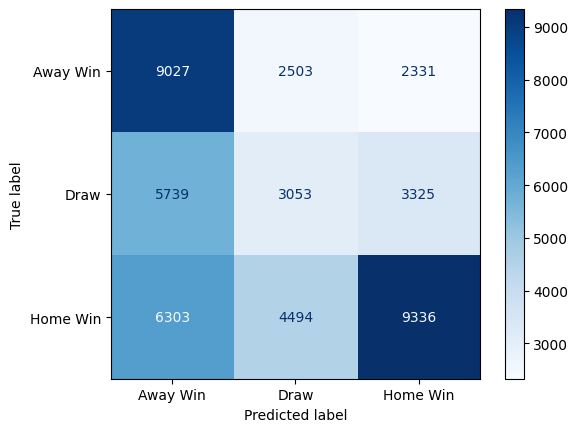

In [38]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, final_pred_lr, cmap="Blues", values_format='d',
    display_labels=['Away Win', 'Draw', 'Home Win']
)
plt.show()

## Random Forest

In [25]:
print("Accuracy:", accuracy_score(y_test, final_pred_rf))

Accuracy: 0.473813189911301


In [27]:
report_dict_rf = classification_report(y_test, final_pred_rf,
                                     target_names=['Away Win', 'Draw', 'Home Win'],
                                     output_dict=True)
report_rf = pd.DataFrame(report_dict_rf).transpose()
report_rf = report_rf.drop('accuracy')
styled_table_rf = report_rf.style.format("{:.2f}") \
                             .set_properties(**{'text-align': 'center', 'font-family': 'Arial'}) \
                             .set_table_styles([{'selector': 'th', 'props': [('font-size', '12pt'), ('background-color', '#f4f4f4')]}])
styled_table_rf

,precision,recall,f1-score,support
Away Win,0.45,0.59,0.51,13861.00
Draw,0.31,0.27,0.29,12117.00
Home Win,0.60,0.52,0.56,20133.00
macro avg,0.45,0.46,0.45,46111.00
weighted avg,0.48,0.47,0.47,46111.00


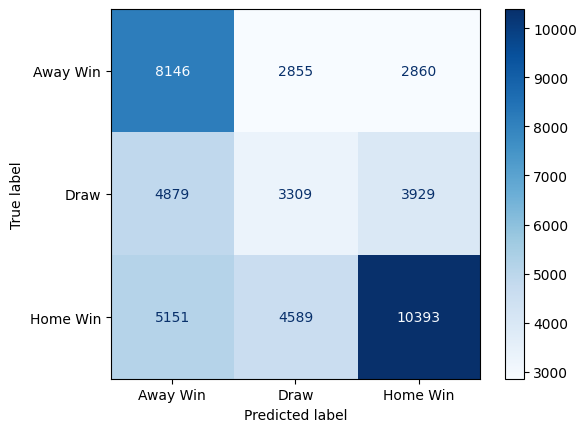

In [13]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, final_pred_rf, cmap="Blues", values_format='d',
    display_labels=['Away Win', 'Draw', 'Home Win']
)
plt.show()

In [ ]:
feature_names = preprocessor.get_feature_names_out()
importances = final_model_rf.feature_importances_
feat_importances = pd.Series(importances, index=feature_names)
print(feat_importances.sort_values(ascending=False))

num__ProbAway     0.305516
num__ProbHome     0.273884
num__elo_diff     0.102678
num__xG_Diff      0.091042
num__ProbDraw     0.089059
num__xG_Away      0.049308
num__xG_Home      0.038399
num__FormDiff5    0.018965
num__HomeElo      0.006872
num__Form5Away    0.006046
num__AwayElo      0.005925
num__FormDiff3    0.005884
num__Form5Home    0.004185
num__Form3Home    0.001365
num__Form3Away    0.000873
dtype: float64


## XGBoost

In [35]:
print("XGBoost Accuracy:", accuracy_score(y_test, final_pred_xgb))

XGBoost Accuracy: 0.4841144195528182


In [34]:
report_dict_xgb = classification_report(y_test, final_pred_xgb,
                                     target_names=['Away Win', 'Draw', 'Home Win'],
                                     output_dict=True)
report_xgb = pd.DataFrame(report_dict_xgb).transpose()
report_xgb = report_xgb.drop('accuracy')
styled_table_xgb = report_xgb.style.format("{:.2f}") \
                             .set_properties(**{'text-align': 'center', 'font-family': 'Arial'}) \
                             .set_table_styles([{'selector': 'th', 'props': [('font-size', '12pt'), ('background-color', '#f4f4f4')]}])
styled_table_xgb

,precision,recall,f1-score,support
Away Win,0.50,0.42,0.46,13861.00
Draw,0.31,0.30,0.31,12117.00
Home Win,0.56,0.64,0.60,20133.00
macro avg,0.46,0.45,0.45,46111.00
weighted avg,0.48,0.48,0.48,46111.00


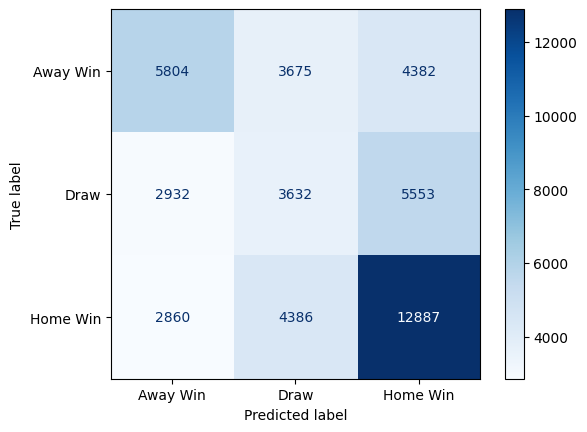

In [36]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, final_pred_xgb, cmap="Blues", values_format='d',
    display_labels=['Away Win', 'Draw', 'Home Win']
)
plt.show()

In [ ]:
feature_names = preprocessor.get_feature_names_out()
importances = final_model_xgb.feature_importances_
feat_importances = pd.Series(importances, index=feature_names)
print(feat_importances.sort_values(ascending=False))

num__ProbAway     0.361976
num__ProbHome     0.352728
num__ProbDraw     0.086344
num__xG_Diff      0.033529
num__elo_diff     0.026927
num__xG_Away      0.015272
num__xG_Home      0.015023
num__FormDiff5    0.014736
num__Form3Home    0.013991
num__Form5Away    0.013600
num__AwayElo      0.013480
num__Form3Away    0.013417
num__HomeElo      0.013112
num__FormDiff3    0.013028
num__Form5Home    0.012837
dtype: float32


# Wykresy

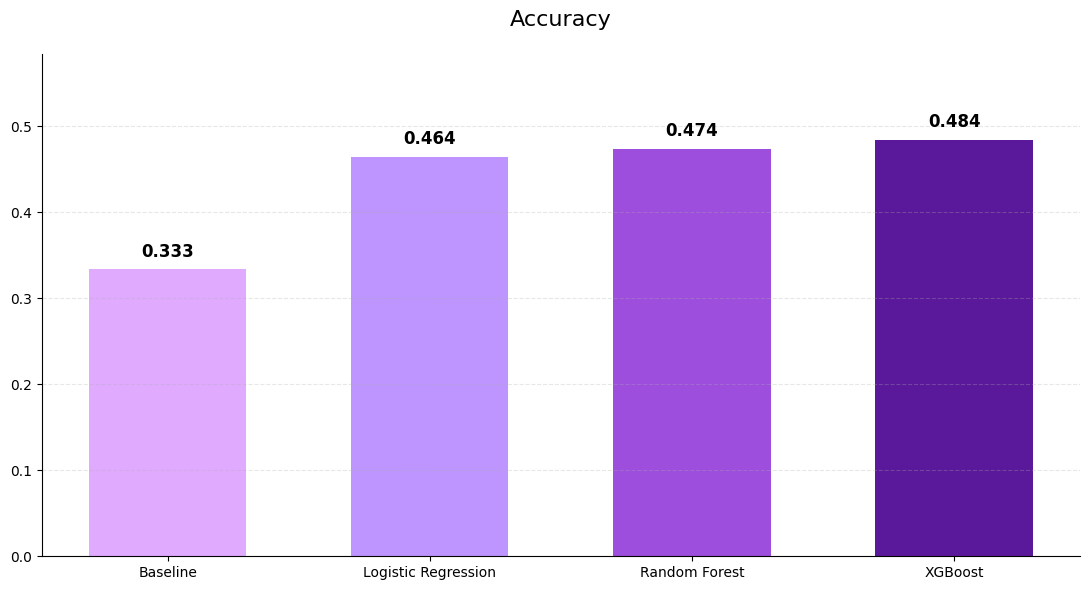

In [69]:
models = ['Baseline', 'Logistic Regression', 'Random Forest', 'XGBoost']
accuracy_scores = [accuracy_score(y_test, y_baseline_pred),
                   accuracy_score(y_test, final_pred_lr),
                   accuracy_score(y_test, final_pred_rf),
                   accuracy_score(y_test, final_pred_xgb)]

colors = ['#E0AAFF', '#BE95FF', '#9D4EDD','#5A189A']

plt.figure(figsize=(11, 6))
bars = plt.bar(models, accuracy_scores, color=colors, width=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Accuracy', fontsize=16, pad=20)
plt.ylim(0, max(accuracy_scores) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

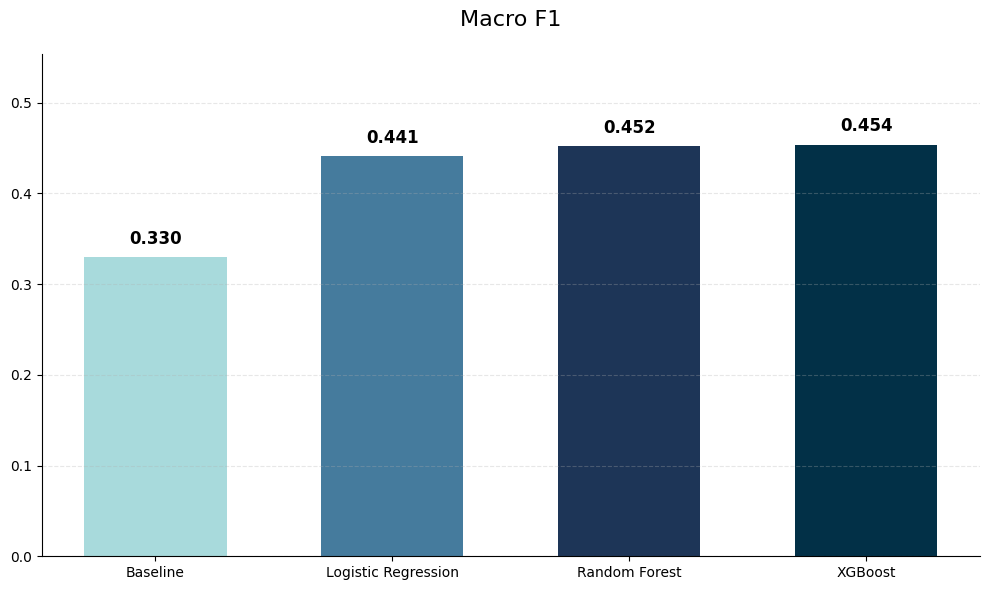

In [68]:
models = ['Baseline', 'Logistic Regression', 'Random Forest', 'XGBoost']
f1_scores = [f1_score(y_test, y_baseline_pred, average='macro'),
             f1_score(y_test, final_pred_lr, average='macro'),
             f1_score(y_test, final_pred_rf, average='macro'),
             f1_score(y_test, final_pred_xgb, average='macro')]

plt.figure(figsize=(10, 6))
colors = ['#A8DADC','#457B9D','#1D3557','#023047']
bars = plt.bar(models, f1_scores, color=colors, width=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Macro F1', fontsize=16, pad=20)
plt.ylim(0, max(f1_scores) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()